#### Предсказываем цену ноутбука

В папке лежит датасет laptop_prices, в котором содержатся сведения о ноутбуках, их характеристики и цены. Обучите модель линейной регрессии, которая будет предсказывать цену ноутбука по его характеристикам. 

Придется хорошенько поработать с характеристиками: это *творческая* часть задания. Во-первых, надо привести их в машиночитаемый вид, а во-вторых, можно посмотреть, как они коррелируют друг с другом и не нужно ли кого-то из них дропнуть или наоборот. Не советую бездумно использовать OHE: некоторые признаки явно можно закодировать куда более оптимальным способом. 

*Примечание*: без работы над фичами за все дз - **0 баллов**. 

In [409]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pylab as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [410]:
data = pd.read_csv('laptop_prices.csv')
data.head()

,Brand,Processor,RAM (GB),Storage,GPU,Screen Size (inch),Resolution,Battery Life (hours),Weight (kg),Operating System,Price ($)
0,Apple,AMD Ryzen 3,64,512GB SSD,Nvidia GTX 1650,17.3,2560x1440,8.9,1.42,FreeDOS,3997.07
1,Razer,AMD Ryzen 7,4,1TB SSD,Nvidia RTX 3080,14.0,1366x768,9.4,2.57,Linux,1355.78
2,Asus,Intel i5,32,2TB SSD,Nvidia RTX 3060,13.3,3840x2160,8.5,1.74,FreeDOS,2673.07
3,Lenovo,Intel i5,4,256GB SSD,Nvidia RTX 3080,13.3,1366x768,10.5,3.10,Windows,751.17
4,Razer,Intel i3,4,256GB SSD,AMD Radeon RX 6600,16.0,3840x2160,5.7,3.38,Linux,2059.83


In [411]:
headers = ['Brand','Processor', 'RAM (GB)', 'Storage', 'GPU', 'Screen Size (inch)', 'Resolution', 'Battery Life (hours)', 'Weight (kg)', 'Operating System']
for i in headers:
    unique = data[i].unique()
    print(i, unique, type(data[i].unique()[0]))

Brand ['Apple' 'Razer' 'Asus' 'Lenovo' 'Acer' 'Dell' 'Microsoft' 'HP' 'Samsung'
 'MSI'] <class 'str'>
Processor ['AMD Ryzen 3' 'AMD Ryzen 7' 'Intel i5' 'Intel i3' 'AMD Ryzen 9'
 'AMD Ryzen 5' 'Intel i9' 'Intel i7'] <class 'str'>
RAM (GB) [64  4 32  8 16] <class 'numpy.int64'>
Storage ['512GB SSD' '1TB SSD' '2TB SSD' '256GB SSD' '1TB HDD'] <class 'str'>
GPU ['Nvidia GTX 1650' 'Nvidia RTX 3080' 'Nvidia RTX 3060'
 'AMD Radeon RX 6600' 'Nvidia RTX 2060' 'AMD Radeon RX 6800' 'Integrated'] <class 'str'>
Screen Size (inch) [17.3 14.  13.3 16.  15.6] <class 'numpy.float64'>
Resolution ['2560x1440' '1366x768' '3840x2160' '1920x1080'] <class 'str'>
Battery Life (hours) [ 8.9  9.4  8.5 10.5  5.7  7.1  9.1  9.8 11.5  7.5  6.4  8.3  9.3 10.9
 11.8  7.8 11.6 10.   7.2 11.4  7.  11.9  6.9  4.4  6.2  9.9  5.4  4.9
  5.   7.6  8.   6.6 11.3 10.3  4.5  9.6 11.1  5.9  4.8  4.6  8.2  8.1
  5.3  6.3  4.3  9.7  5.1 10.1 11.2  6.1 10.7  4.7  4.1  4.2  8.6  7.9
 10.8  5.8  6.7 11.   9.5  5.5  9.2 10.6  6.5  7

In [412]:
data.isnull().sum()
#все данные заполнены, ура

Brand                   0
Processor               0
RAM (GB)                0
Storage                 0
GPU                     0
Screen Size (inch)      0
Resolution              0
Battery Life (hours)    0
Weight (kg)             0
Operating System        0
Price ($)               0
dtype: int64

In [413]:
from functools import reduce
import operator

In [414]:
def strtoint(line):
    numbers = ''.join(c if c.isdigit() else ' ' for c in line).split()
    return(reduce(operator.mul, list(map(int, numbers))))

In [415]:
def tbtogb(line):
    numbers = int(''.join(c if c.isdigit() else ' ' for c in line))
    if numbers < 3:
        return numbers * 1024
    else:
        return numbers

In [416]:
strtoint('1920x1080')

2073600

In [417]:
tbtogb('2TB SSD')

2048

In [418]:
itac = data[['Processor', 'GPU', 'Screen Size (inch)','Resolution']].copy()
itac['Resolution'] = itac['Resolution'].apply(strtoint)
itac  = pd.get_dummies(itac, drop_first=True)
itac

,Screen Size (inch),Resolution,Processor_AMD Ryzen 5,Processor_AMD Ryzen 7,Processor_AMD Ryzen 9,Processor_Intel i3,Processor_Intel i5,Processor_Intel i7,Processor_Intel i9,GPU_AMD Radeon RX 6800,GPU_Integrated,GPU_Nvidia GTX 1650,GPU_Nvidia RTX 2060,GPU_Nvidia RTX 3060,GPU_Nvidia RTX 3080
0,17.3,3686400,False,False,False,False,False,False,False,False,False,True,False,False,False
1,14.0,1049088,False,True,False,False,False,False,False,False,False,False,False,False,True
2,13.3,8294400,False,False,False,False,True,False,False,False,False,False,False,True,False
3,13.3,1049088,False,False,False,False,True,False,False,False,False,False,False,False,True
4,16.0,8294400,False,False,False,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11763,17.3,1049088,False,False,False,True,False,False,False,False,False,False,True,False,False
11764,16.0,1049088,False,False,False,True,False,False,False,True,False,False,False,False,False
11765,15.6,3686400,False,False,True,False,False,False,False,False,False,False,False,False,False
11766,13.3,2073600,False,True,False,False,False,False,False,False,True,False,False,False,False


In [419]:
data['Resolution'] = data['Resolution'].apply(strtoint)
data['Storage (GB)'] = data['Storage'].apply(tbtogb)
data['SSD'] = data['Storage'].apply(lambda x: 1 if'SSD' in x else 0)
data = data.drop('Storage', axis=1)
data = data.drop('Weight (kg)', axis = 1)
data = data.drop('Battery Life (hours)', axis = 1)
data = data.drop('Storage (GB)', axis = 1)
#data = data.drop('Screen Size (inch)', axis = 1)
#data = data.drop('Resolution', axis = 1)
data  = pd.get_dummies(data, drop_first=True)
data

,RAM (GB),Screen Size (inch),Resolution,Price ($),SSD,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,...,Processor_Intel i9,GPU_AMD Radeon RX 6800,GPU_Integrated,GPU_Nvidia GTX 1650,GPU_Nvidia RTX 2060,GPU_Nvidia RTX 3060,GPU_Nvidia RTX 3080,Operating System_Linux,Operating System_Windows,Operating System_macOS
0,64,17.3,3686400,3997.07,1,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,4,14.0,1049088,1355.78,1,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False
2,32,13.3,8294400,2673.07,1,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,4,13.3,1049088,751.17,1,False,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False
4,4,16.0,8294400,2059.83,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11763,4,17.3,1049088,704.82,1,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
11764,4,16.0,1049088,775.59,1,False,True,False,False,False,...,False,True,False,False,False,False,False,True,False,False
11765,4,15.6,3686400,2789.46,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
11766,16,13.3,2073600,1067.13,1,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True


In [420]:
y = data['Price ($)']
X = data.drop('Price ($)', axis=1)

In [421]:
# your code here
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(Xtrain, ytrain) # обучение модели
pred_train = model.predict(Xtrain)
pred_test = model.predict(Xtest)

In [422]:
pred_train

array([1167.44077038, 2739.88480172, 1745.08950645, ..., 2810.50630215,
       3338.32450181, 1064.71430787])

In [423]:
ytest

10445    1240.54
6057     1469.29
10999    2153.12
11310     970.92
11258    1479.22
          ...   
3650      570.97
7680     2204.41
7073     1992.14
1330     1364.60
7791     1930.75
Name: Price ($), Length: 2354, dtype: float64

In [424]:
pred_test

array([ 922.75699996, 1305.64546432, 2445.51703987, ..., 2010.3276127 ,
       1678.04155995, 2702.80248279])

In [425]:
trainMSE = mean_squared_error(pred_train, ytrain) ** 0.5
testMSE = mean_squared_error(pred_test, ytest) ** 0.5
print(trainMSE, testMSE)
print(f'{trainMSE/data['Price ($)'].mean() * 100}%, {testMSE/data['Price ($)'].mean() * 100}%')

456.81351371970766 469.0459064433458
20.920473232863376%, 21.480674358405746%


In [426]:
coef = model.coef_.tolist() # веса при признаках
intercept = model.intercept_# свободный коэффициент (w0)
a = list(zip(X.columns, coef))
#print(coef, intercept)
a

[('RAM (GB)', 37.604516834760574),
 ('Screen Size (inch)', 59.115857377172546),
 ('Resolution', 0.00019874394096540795),
 ('SSD', 376.2462907662693),
 ('Brand_Apple', 978.512308786269),
 ('Brand_Asus', 11.896903893236857),
 ('Brand_Dell', 12.56528832917531),
 ('Brand_HP', 31.805617238013774),
 ('Brand_Lenovo', -11.619654379784846),
 ('Brand_MSI', 595.8804091049522),
 ('Brand_Microsoft', 21.52151894435334),
 ('Brand_Razer', 775.4275667428456),
 ('Brand_Samsung', 19.80730832510185),
 ('Processor_AMD Ryzen 5', 308.1393567316909),
 ('Processor_AMD Ryzen 7', 730.3805736411424),
 ('Processor_AMD Ryzen 9', 1508.394459873258),
 ('Processor_Intel i3', -24.941464282122126),
 ('Processor_Intel i5', 288.86203914538595),
 ('Processor_Intel i7', 735.5014279416648),
 ('Processor_Intel i9', 1492.2485459511836),
 ('GPU_AMD Radeon RX 6800', 19.258719539542394),
 ('GPU_Integrated', -683.7004359837413),
 ('GPU_Nvidia GTX 1650', 33.78344864707798),
 ('GPU_Nvidia RTX 2060', 16.13159769893777),
 ('GPU_Nvidia

<Axes: >

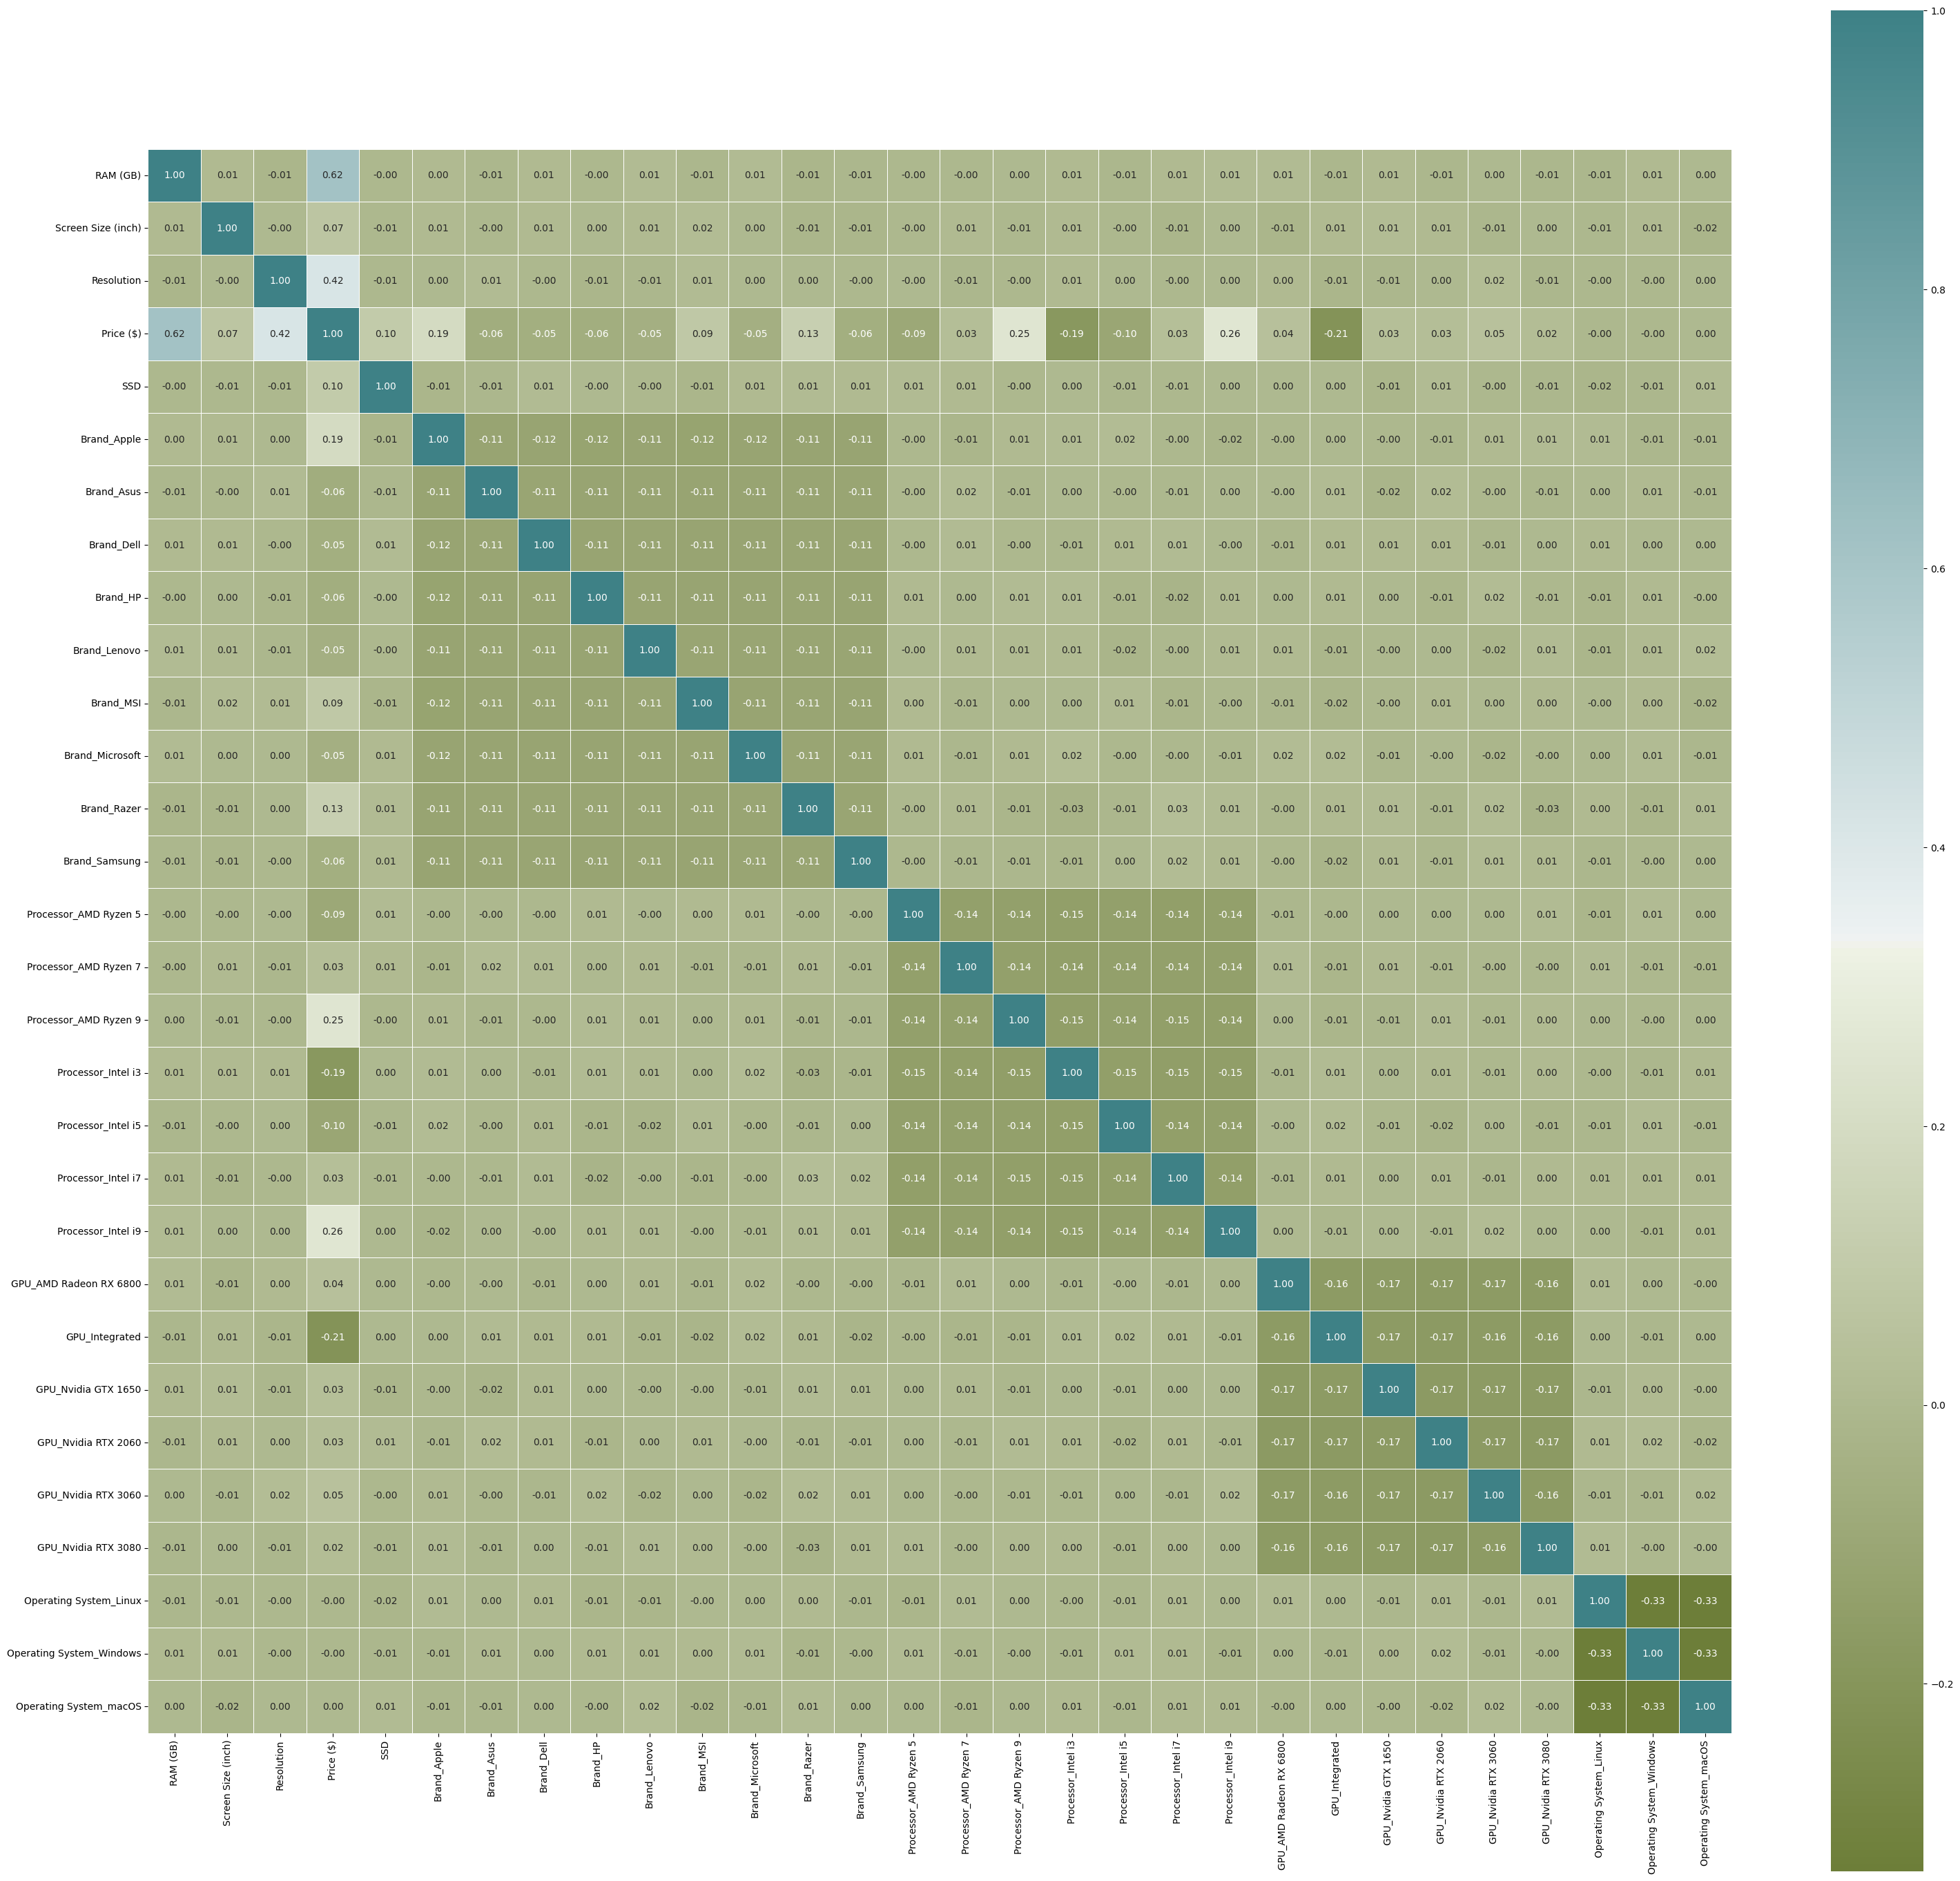

In [427]:
plt.figure(figsize=(37,35))

corr = data.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)

RAM (GB)


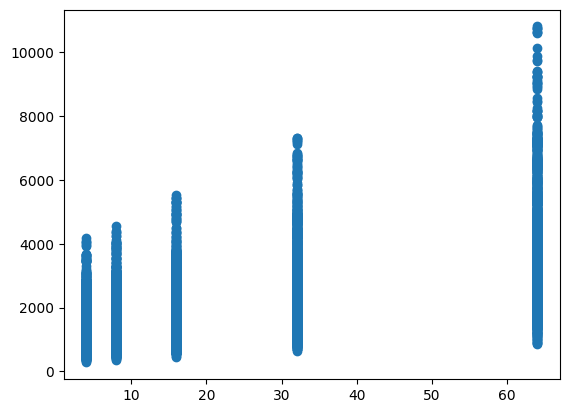

Screen Size (inch)


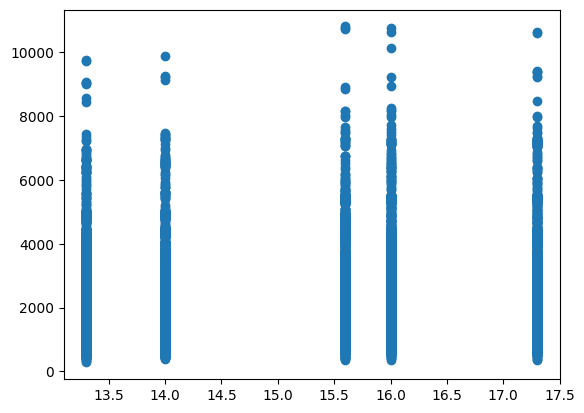

Resolution


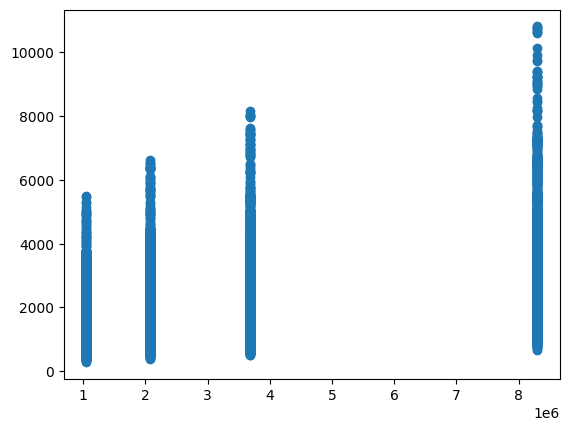

SSD


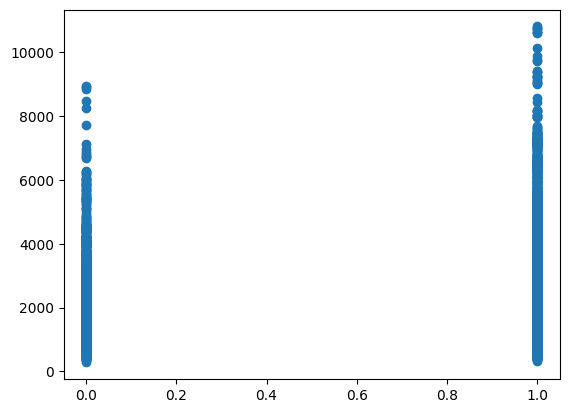

Brand_Apple


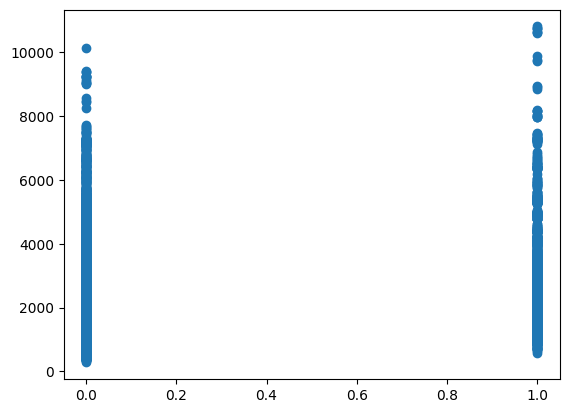

Brand_Asus


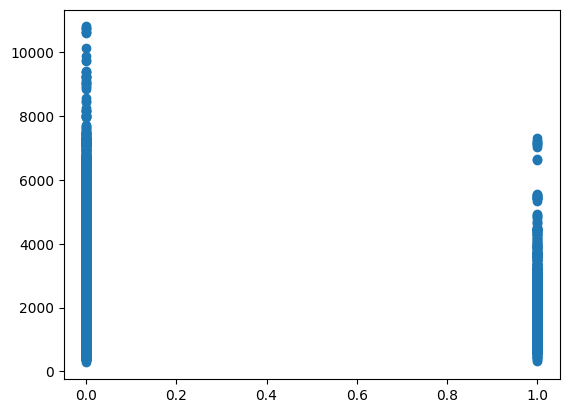

Brand_Dell


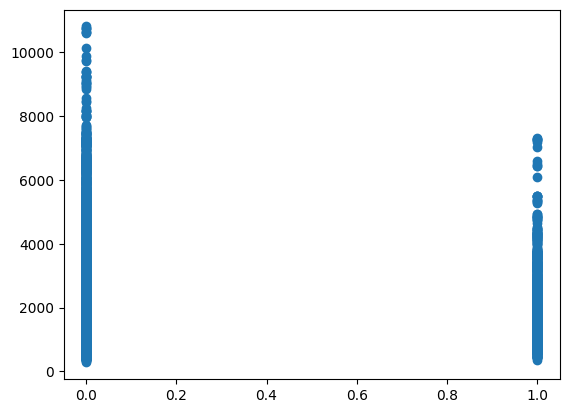

Brand_HP


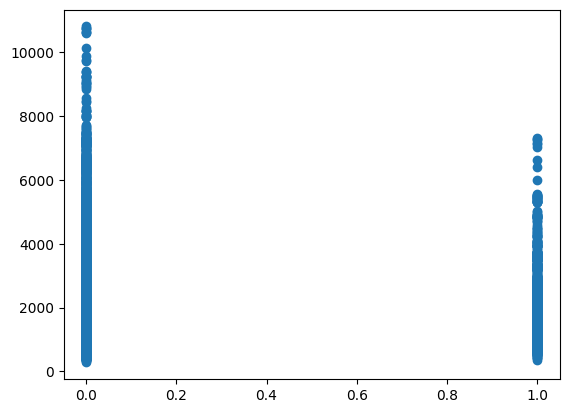

Brand_Lenovo


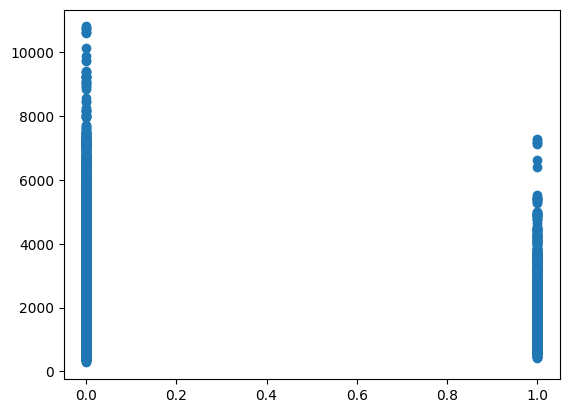

Brand_MSI


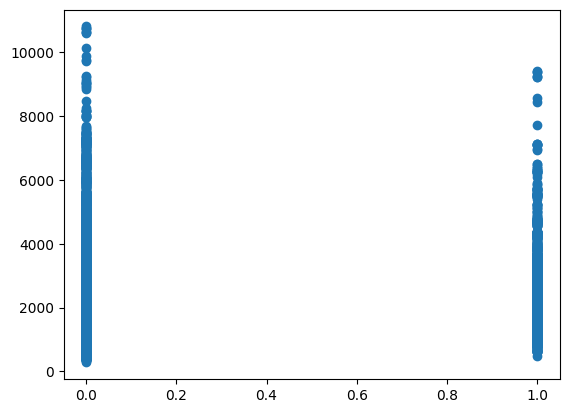

Brand_Microsoft


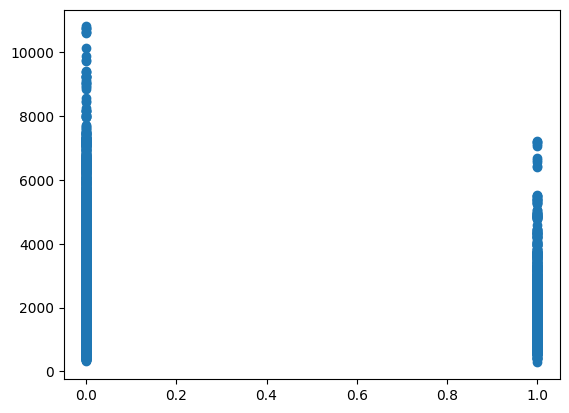

Brand_Razer


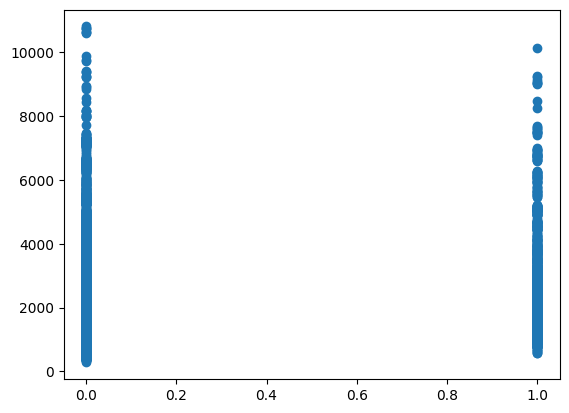

Brand_Samsung


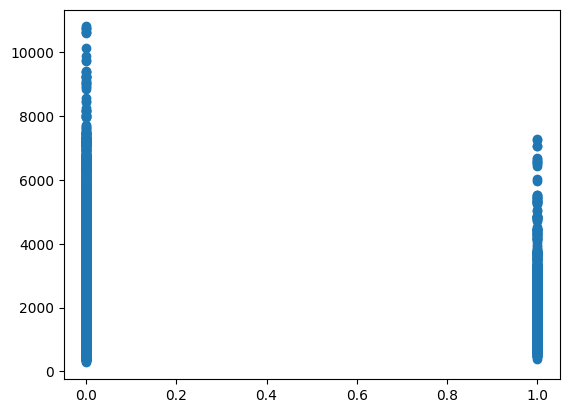

Processor_AMD Ryzen 5


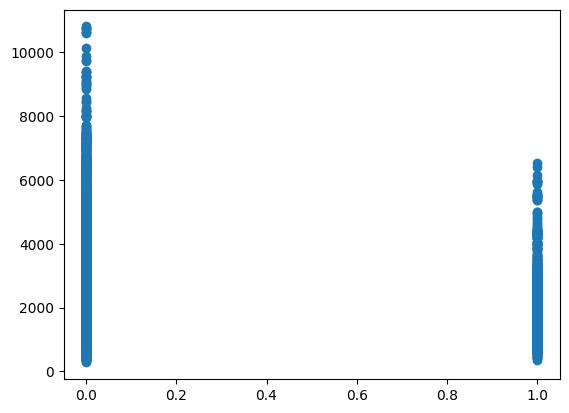

Processor_AMD Ryzen 7


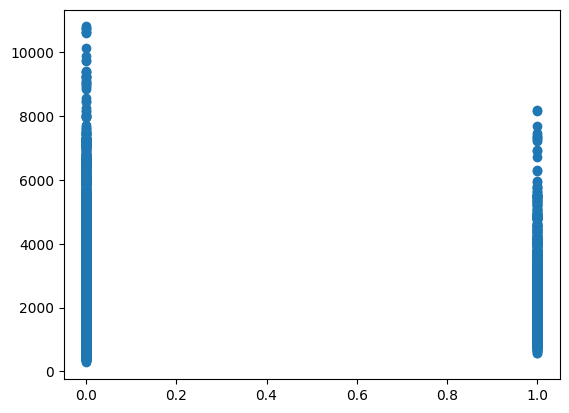

Processor_AMD Ryzen 9


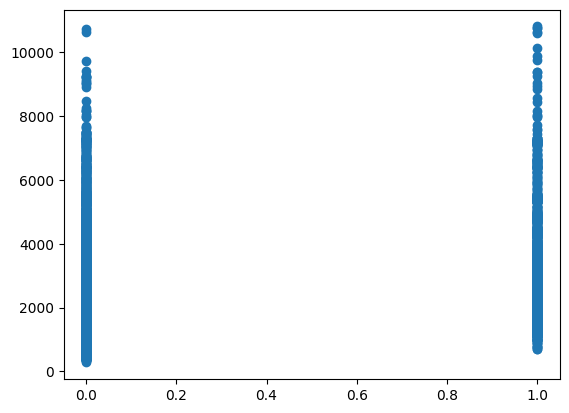

Processor_Intel i3


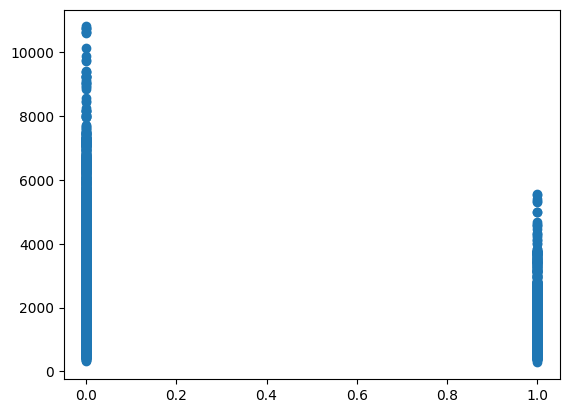

Processor_Intel i5


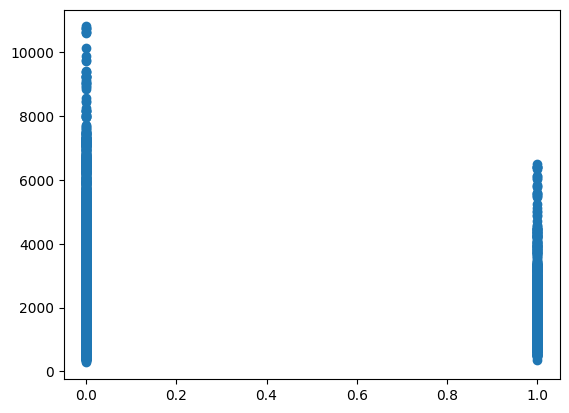

Processor_Intel i7


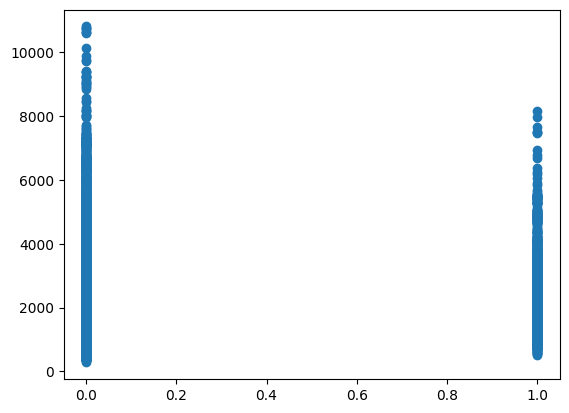

Processor_Intel i9


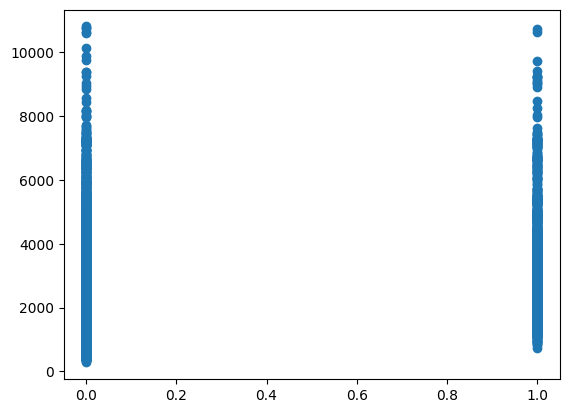

GPU_AMD Radeon RX 6800


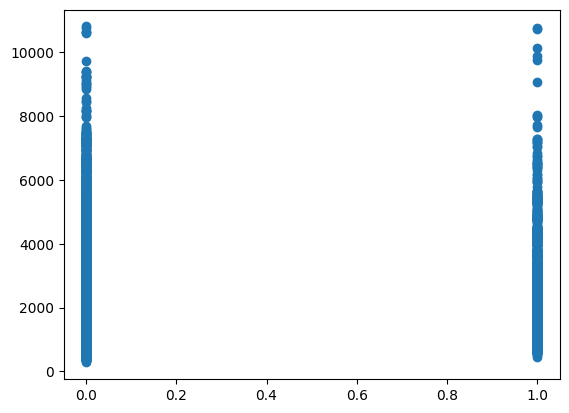

GPU_Integrated


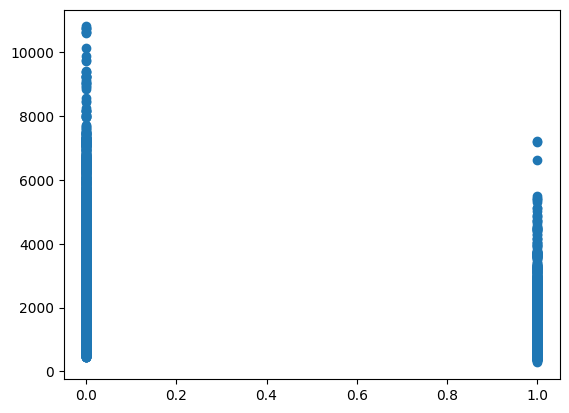

GPU_Nvidia GTX 1650


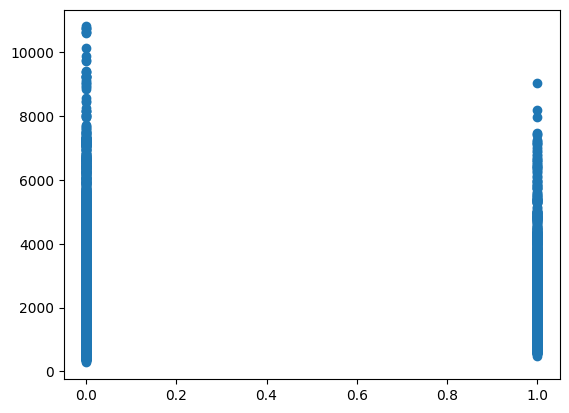

GPU_Nvidia RTX 2060


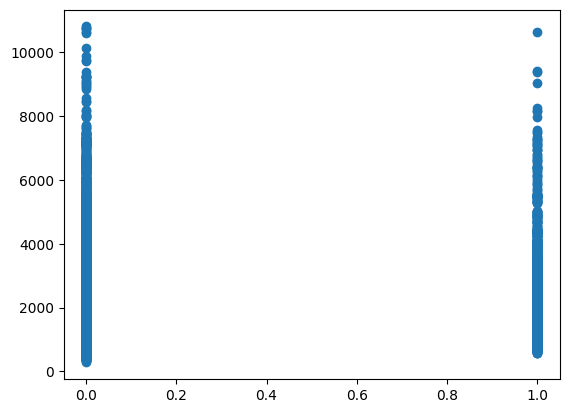

GPU_Nvidia RTX 3060


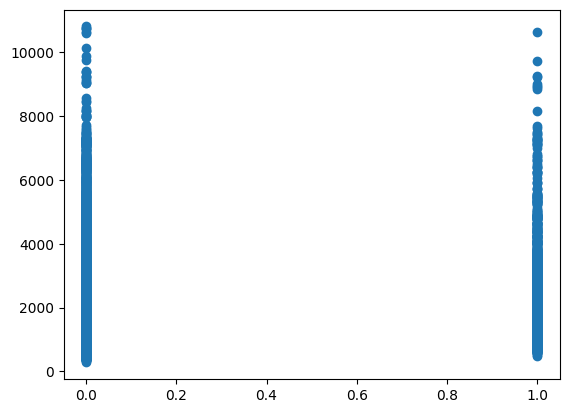

GPU_Nvidia RTX 3080


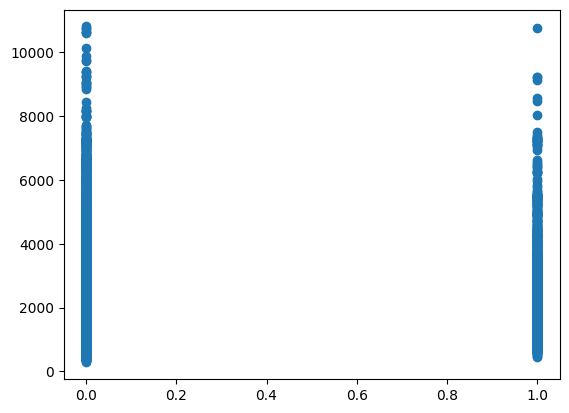

Operating System_Linux


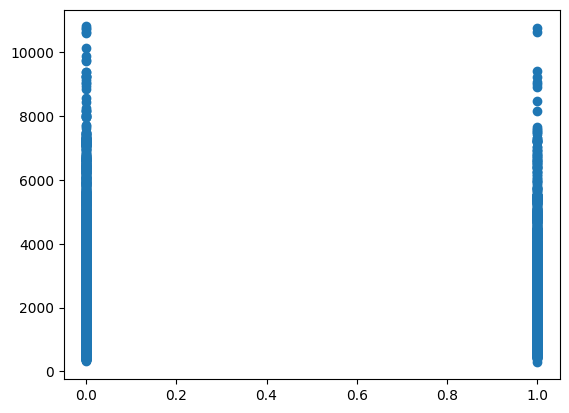

Operating System_Windows


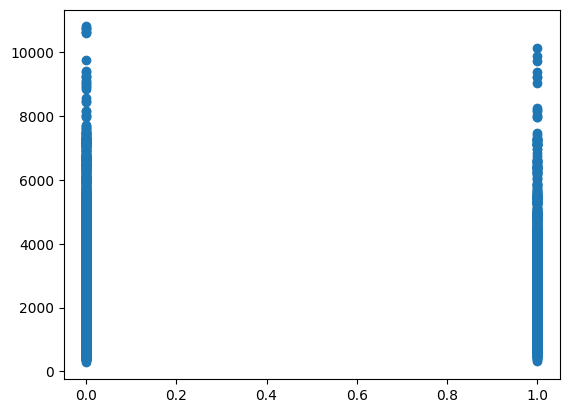

Operating System_macOS


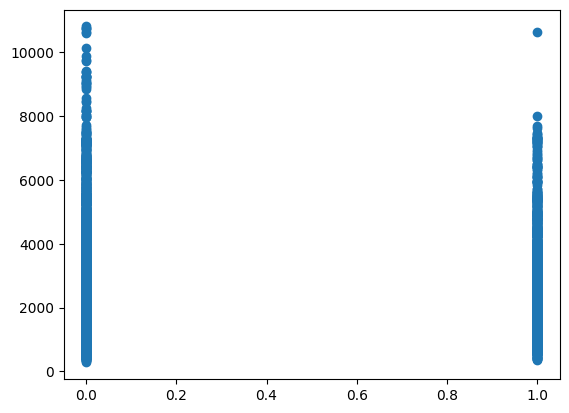

In [428]:
for c in data.columns:
    if c != 'Price ($)':
        print(c)
        plt.scatter(data[c], data['Price ($)'])
        plt.show()